In [61]:
#MAXWELL TURNER - ASSIGNMENT 2.5 - BANKNOTE MLP - WEEK 2

In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [63]:
#data 2.2
df = pd.read_csv("../data/banknote-auth.csv")
feats = ["variance", "skewness", "kurtosis", "entropy"]
X = df[feats].to_numpy()
y = df["label"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("train:", X_train.shape, "test:", X_test.shape)

train: (1097, 4) test: (275, 4)


In [64]:
#Tensors
X_train_t = torch.from_numpy(X_train).float()
X_test_t = torch.from_numpy(X_test).float()
y_train_t = torch.from_numpy(y_train).float().view(-1, 1)
y_test_t = torch.from_numpy(y_test).float().view(-1, 1)
print(X_train_t.shape, y_train_t.shape)

torch.Size([1097, 4]) torch.Size([1097, 1])


In [65]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, output_dim=1):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = self.hidden(x)
        x = F.relu(x)
        x = self.output(x)
        x = torch.sigmoid(x)
        return x

In [66]:
# lr=0.5 because 20 epochs is only 20 updates small lr barely moves
torch.manual_seed(42)
model = SimpleMLP(input_dim=4, hidden_dim=16, output_dim=1)
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
for epoch in range(20):
    pred = model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    optimizer.zero_grad()
    loss.backward() 
    optimizer.step()
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1:>3}  loss {loss.item():.4f}")

epoch   5  loss 0.1949
epoch  10  loss 0.1041
epoch  15  loss 0.0722
epoch  20  loss 0.0550


In [67]:
# no_grad because im just checking not training
with torch.no_grad():
    train_pred = (model(X_train_t) > 0.5).float()
    test_pred = (model(X_test_t) > 0.5).float()
    train_acc = accuracy_score(y_train_t.numpy(), train_pred.numpy())
    test_acc = accuracy_score(y_test_t.numpy(), test_pred.numpy())
    cm = confusion_matrix(y_test_t.numpy(), test_pred.numpy())
print(f"train accuracy: {train_acc:.4f}")
print(f"test accuracy:  {test_acc:.4f}")
print()
print(cm)

train accuracy: 0.9909
test accuracy:  0.9927

[[146   2]
 [  0 127]]


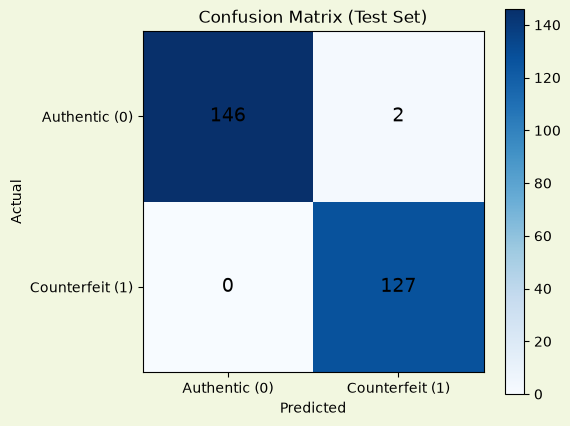

In [68]:
# same imshow trick as the heatmap
plt.figure(figsize=(5.5, 5))
plt.gcf().set_facecolor("#f2f7e0")
plt.imshow(cm, cmap="Blues")
plt.colorbar()
labels = ["Authentic (0)", "Counterfeit (1)"]
plt.xticks(range(2), labels)
plt.yticks(range(2), labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
plt.title("Confusion Matrix (Test Set)")
plt.show()

#only 2 wrong out of 275. the 2 misses were authentic notes flagged as fake,
#and it caught every single counterfeit. for detecting fake money thats the
#better way to be wrong, way rather double check a real note than let a fake
#one through.

In [69]:
# helper so I can test different settings without copy pasting the loop
def run(lr, epochs, hidden):
    torch.manual_seed(42)
    m = SimpleMLP(input_dim=4, hidden_dim=hidden, output_dim=1)
    fn = nn.BCELoss()
    op = torch.optim.SGD(m.parameters(), lr=lr)
    for _ in range(epochs):
        p = m(X_train_t)
        l = fn(p, y_train_t)
        op.zero_grad()
        l.backward()
        op.step()
    with torch.no_grad():
        tr = accuracy_score(y_train_t.numpy(), (m(X_train_t) > 0.5).float().numpy())
        te = accuracy_score(y_test_t.numpy(), (m(X_test_t) > 0.5).float().numpy())
    return tr, te

In [70]:
print("=== learning rate and epochs (hidden=16) ===")
for lr, ep in [(0.01, 20), (0.1, 20), (0.5, 20), (0.5, 5), (0.5, 50), (2.0, 20), (5.0, 20)]:
    tr, te = run(lr, ep, 16)
    print(f"  lr={lr:<6} epochs={ep:<4} train={tr:.4f} test={te:.4f}")
print()
print("=== hidden layer size (lr=0.5, epochs=20) ===")
for h in [1, 2, 4, 16, 64, 256]:
    tr, te = run(0.5, 20, h)
    print(f"  hidden={h:<5} train={tr:.4f} test={te:.4f}")


#what I noticed:
#lr matters a lot. 0.01 only got 91%, but 0.5 got 99%. it kept improving up
#to 2.0 then got WORSE at 5.0, so there's a sweet spot and past it the steps
#are too big and it overshoots.
#more epochs helped. 5 epochs wasn't enough, 50 got 100%. makes sense since
#each epoch is only one weight update here.
#hidden size barely mattered except hidden=2 which totally died at 56%.
#that's basically just guessing the bigger class.

=== learning rate and epochs (hidden=16) ===
  lr=0.01   epochs=20   train=0.9134 test=0.9055
  lr=0.1    epochs=20   train=0.9517 test=0.9309
  lr=0.5    epochs=20   train=0.9909 test=0.9927
  lr=0.5    epochs=5    train=0.9499 test=0.9236
  lr=0.5    epochs=50   train=1.0000 test=1.0000
  lr=2.0    epochs=20   train=0.9964 test=0.9964
  lr=5.0    epochs=20   train=0.9626 test=0.9636

=== hidden layer size (lr=0.5, epochs=20) ===
  hidden=1     train=0.9909 test=0.9891
  hidden=2     train=0.5597 test=0.5382
  hidden=4     train=0.9854 test=0.9891
  hidden=16    train=0.9909 test=0.9927
  hidden=64    train=0.9964 test=0.9964
  hidden=256   train=0.9936 test=0.9964


In [71]:
#response for q1-- Did the model perform similarly on the training and test sets?
#Yeah, almost identical. 99.09% on train and 99.27% on test, so the test score
#was actually a tiny bit higher. That means it's not overfitting at all, it
#learned the real pattern instead of memorizing the training notes. If train
#had been way higher than test I'd be worried it just memorized. The confusion
#matrix backs this up, only 2 wrong out of 275 and it caught every counterfeit.

#response for q2-- What happens if we modify the learning rate and epochs?
#Both changed the results a lot. At lr=0.01 it only hit 91% because the steps
#were too small to get anywhere in 20 epochs. Bumping it to 0.5 got 99% and 2.0
#was about the same, but at 5.0 it dropped back down. So there's a sweet spot,
#and going past it means the steps are so big it overshoots the good answer
#instead of settling into it. Epochs did the same kind of thing, 5 epochs
#wasn't enough at 95%, 20 got 99%, and 50 got a perfect 100%. The reason epochs
#matter so much here is that the whole training set goes through at once, so
#one epoch is literally one weight update. 20 epochs is only 20 adjustments.

#response for q3-- What happens if you adjust the size of the hidden layer?
#Mostly not much, which surprised me. hidden=1, 4, 16, 64, and 256 all landed
#around 98-99%, so this problem doesn't need a big network. The weird one was
#hidden=2 which crashed to 56%. That's basically the same as just guessing
#"authentic" every time since that's 55% of the data, so the network gave up
#and stopped learning. I think with only 2 ReLU neurons and unlucky starting
#weights both of them got stuck in the flat part of ReLU where the gradient is
#0, so they never recovered. It's not that smaller is worse though, since
#hidden=1 worked fine. It was just bad luck with that seed.